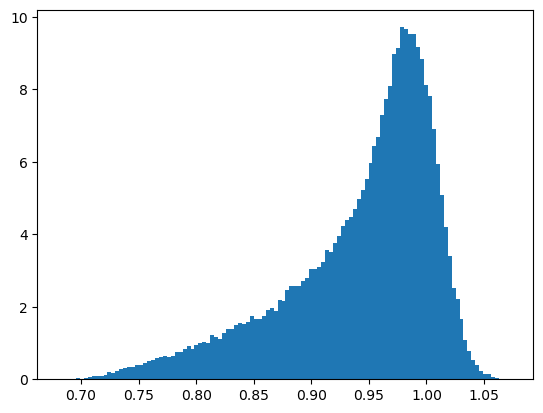

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization.hist import hist

mean = 1
std = 0.02


chi = np.random.uniform(0, 1, 100000)

M = np.random.normal(mean, std, 100000)

M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)

x = np.linspace(min(M_irr), max(M_irr))

hist(M_irr, bins="freedman", density=True);

In [22]:
from sklearn.neighbors import KernelDensity

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x[:, np.newaxis]) # sklearn returns log(density)

    return np.exp(log_pdf)

KDE = kde_sklearn(M_irr,bandwidth=0.1,kernel="linear") 

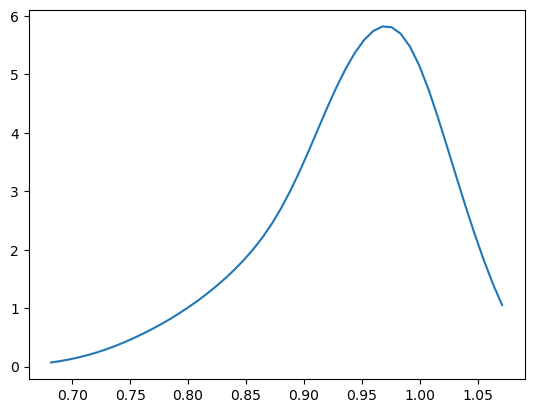

In [23]:
plt.plot(x, KDE) 

In [24]:
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import uniform
import scipy.stats
from scipy import optimize
from astroML import stats as astroMLstats

f = np.sqrt((1+np.sqrt(1-chi**2))/2)
print(stats.ks_2samp(M_irr, f))                 #mean = 1

KstestResult(statistic=0.15827000000000002, pvalue=0.0, statistic_location=0.9999999999977789, statistic_sign=-1)


In [25]:
#do it for many sigmas

sigmas = np.linspace(0, 0.5, 100)
ks_Mirr_f = []
ks_Mirr_M = []

for i in sigmas:
    M = np.random.normal(mean, i, 100000)
    M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)
    f = M_irr/M
    
    ks_Mirr_f.append(scipy.stats.kstest(M_irr, f))
    ks_Mirr_M.append(scipy.stats.kstest(M_irr, M))

In [26]:
print(ks_Mirr_f[1])
a = np.array(ks_Mirr_f)
b = np.array(ks_Mirr_M)
print(a)

KstestResult(statistic=0.08281000000000005, pvalue=1.012863114224741e-298, statistic_location=0.9999999999977789, statistic_sign=-1)
[[0.00000000e+000 1.00000000e+000]
 [8.28100000e-002 1.01286311e-298]
 [1.14680000e-001 0.00000000e+000]
 [1.38220000e-001 0.00000000e+000]
 [1.58530000e-001 0.00000000e+000]
 [1.77070000e-001 0.00000000e+000]
 [1.89980000e-001 0.00000000e+000]
 [2.05680000e-001 0.00000000e+000]
 [2.17280000e-001 0.00000000e+000]
 [2.30090000e-001 0.00000000e+000]
 [2.39480000e-001 0.00000000e+000]
 [2.47630000e-001 0.00000000e+000]
 [2.57870000e-001 0.00000000e+000]
 [2.65490000e-001 0.00000000e+000]
 [2.76000000e-001 0.00000000e+000]
 [2.81700000e-001 0.00000000e+000]
 [2.88840000e-001 0.00000000e+000]
 [2.97120000e-001 0.00000000e+000]
 [3.03050000e-001 0.00000000e+000]
 [3.07320000e-001 0.00000000e+000]
 [3.13850000e-001 0.00000000e+000]
 [3.17750000e-001 0.00000000e+000]
 [3.23670000e-001 0.00000000e+000]
 [3.29290000e-001 0.00000000e+000]
 [3.34030000e-001 0.0000000

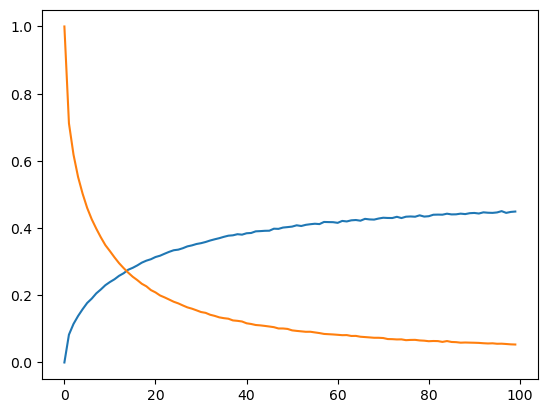

In [27]:
plt.plot(a[:,0])
plt.plot(b[:,0])